In [105]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [106]:
import json
import matplotlib.pyplot as plt

## Neighbor Count vs Delta, Xi

In [107]:
with open("./data/disc_param_sweep.json", 'r+') as f:
    param_sweep_data = json.load(f)

In [108]:
all_xis = list(set([pt['xi'] for pt in param_sweep_data]))
all_deltas = list(set([pt['delta'] for pt in param_sweep_data]))
all_num_nbs = list(set([pt['num_nbs'] for pt in param_sweep_data]))

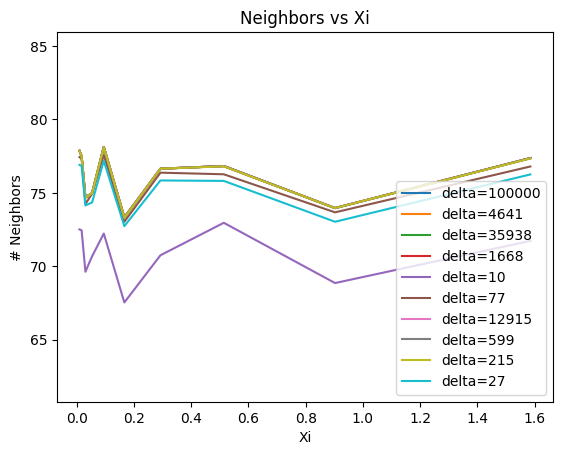

In [110]:
fig = plt.figure()
splt = fig.subplots()
splt.set_ylabel("# Neighbors")
splt.set_xlabel("Xi")
splt.set_title("Neighbors vs Xi")
splt.set_ylim(bottom=min(all_num_nbs)*0.9, top=max(all_num_nbs)*1.1)

for delta in all_deltas:
    plt_y = [pt['num_nbs'] for pt in param_sweep_data if pt['delta'] == delta]
    plt_x = [pt['xi'] for pt in param_sweep_data if pt['delta'] == delta]
    if delta == 100:
        print(plt_y)
    splt.plot(plt_x, plt_y, label=f"delta={delta}")

splt.legend()

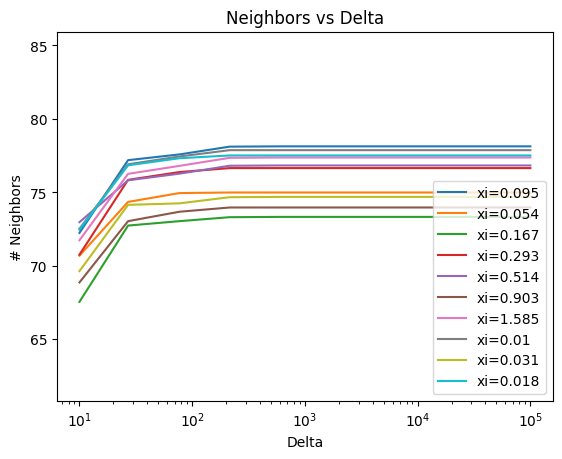

In [117]:
fig = plt.figure()
splt = fig.subplots()
splt.set_ylabel("# Neighbors")
splt.set_xlabel("Delta")
splt.set_title("Neighbors vs Delta")
splt.set_ylim(bottom=min(all_num_nbs)*0.9, top=max(all_num_nbs)*1.1)
splt.set_xscale("log")

for xi in all_xis[::1]:
    plt_y = [pt['num_nbs'] for pt in param_sweep_data if pt['xi'] == xi]
    plt_x = [pt['delta'] for pt in param_sweep_data if pt['xi'] == xi]
    if delta == 100:
        print(plt_y)
    splt.plot(plt_x, plt_y, label=f"xi={round(xi,3)}")

splt.legend()

## PDD Between Original and Reconstructed vs Xi, Delta

In [130]:
with open("./data/pdd_by_xi_delta.json", 'r+') as f:
    pdd_by_xi_delta_data = json.load(f)

all_xis = list(set([pt['xi'] for pt in pdd_by_xi_delta_data]))
all_deltas = list(set([pt['delta'] for pt in pdd_by_xi_delta_data]))
all_pdds = list(set([pt['pdd'] for pt in pdd_by_xi_delta_data]))

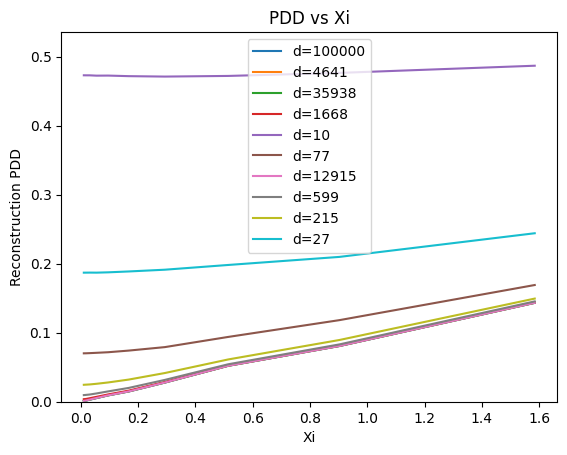

In [131]:
import math

fig = plt.figure()
splt = fig.subplots()
splt.set_ylabel("Reconstruction PDD")
splt.set_xlabel("Xi")
splt.set_title("PDD vs Xi")
splt.set_ylim(bottom=0, top=max(all_pdds) *1.1)

for delta in all_deltas[::1]:
    plt_y = [pt['pdd'] for pt in pdd_by_xi_delta_data if pt['delta'] == delta]
    plt_x = [pt['xi'] for pt in pdd_by_xi_delta_data if pt['delta'] == delta]
    if delta == 100:
        print(plt_y)
    splt.plot(plt_x, plt_y, label=f"d={round(delta)}")


splt.legend()

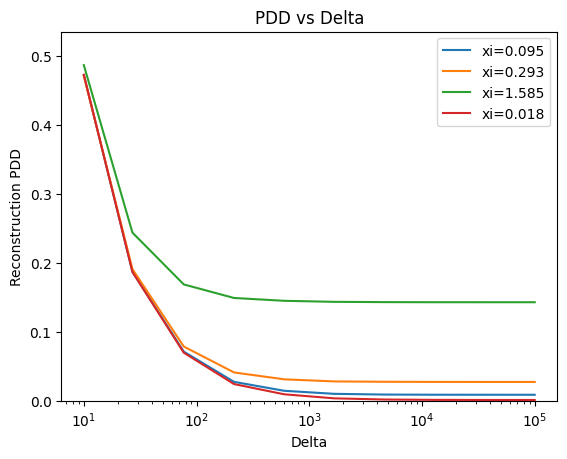

In [132]:
fig = plt.figure()
splt = fig.subplots()
splt.set_ylabel("Reconstruction PDD")
splt.set_xlabel("Delta")
splt.set_title("PDD vs Delta")
splt.set_ylim(bottom=0, top=max(all_pdds) *1.1)
splt.set_xscale("log")
for xi in all_xis[::3]:
    plt_y = [pt['pdd'] for pt in pdd_by_xi_delta_data if pt['xi'] == xi]
    plt_x = [pt['delta'] for pt in pdd_by_xi_delta_data if pt['xi'] == xi]
    if delta == 100:
        print(plt_y)
    splt.plot(plt_x, plt_y, label=f"xi={round(xi, 3)}")

splt.legend()

# Neighbor Count vs Num Atoms

In [135]:
with open("./data/nb_ct_vs_sites.json", 'r+') as f:
    nb_ct_vs_sites_data = json.load(f)

all_num_sites = list(set([pt['num_sites'] for pt in nb_ct_vs_sites_data]))
all_num_nbs = list(set([pt['num_nbs'] for pt in nb_ct_vs_sites_data]))

/var/folders/20/rp8b8xzd0tn81qzlh8zmmvg00000gn/T/ipykernel_94726/4081116222.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  splt.legend()


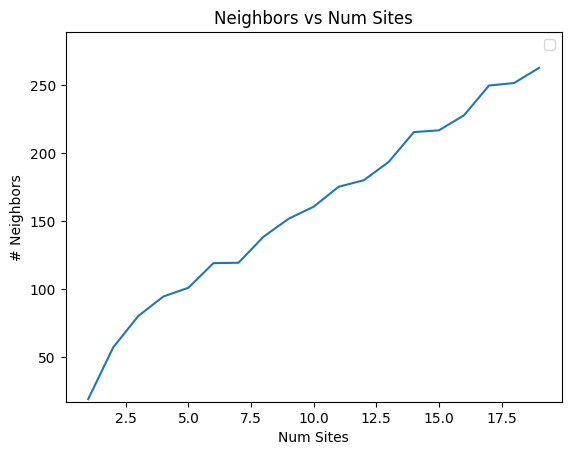

In [137]:
fig = plt.figure()
splt = fig.subplots()
splt.set_ylabel("# Neighbors")
splt.set_xlabel("Num Sites")
splt.set_title("Neighbors vs Num Sites")
splt.set_ylim(bottom=min(all_num_nbs)*0.9, top=max(all_num_nbs)*1.1)

plt_y = [pt['num_nbs'] for pt in nb_ct_vs_sites_data]
plt_x = [pt['num_sites'] for pt in nb_ct_vs_sites_data]
splt.plot(plt_x, plt_y)

splt.legend()

## New neighbor growth

In [175]:
with open("./data/rings.json", 'r+') as f:
    ring_data = json.load(f)

all_num_sites = list(set([pt['num_sites'] for pt in ring_data]))

In [176]:
import numpy as np

compressed = []
for item in ring_data:
    ns = item['num_sites']
    ring_sizes = [[len(ring) for ring in struct] for struct in item['ring_sets']]
    ring_sizes = np.mean(ring_sizes, axis=0)

    growth_factors = []
    prev_ct = 1
    for rs in ring_sizes[1:]:
        growth_factors.append(rs / prev_ct)
        prev_ct = rs
    
    compressed.append({'ns': ns, 'ring_sizes': ring_sizes, 'growth': growth_factors})

In [177]:

compressed

[{'ns': 1,
  'ring_sizes': array([1.0000e+00, 1.2000e+01, 1.0100e+02, 4.8300e+02, 1.7290e+03,
         4.7630e+03, 1.1331e+04, 2.3591e+04, 4.5194e+04]),
  'growth': [12.0,
   8.416666666666666,
   4.782178217821782,
   3.579710144927536,
   2.7547715442452283,
   2.378962838547134,
   2.081987468008119,
   1.9157305752193634]}]

/var/folders/20/rp8b8xzd0tn81qzlh8zmmvg00000gn/T/ipykernel_94726/316373612.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  splt.legend()


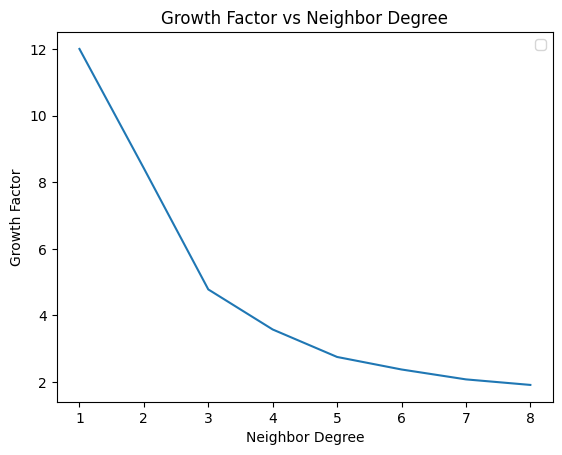

In [178]:
fig = plt.figure()
splt = fig.subplots()
splt.set_ylabel("Growth Factor")
splt.set_xlabel("Neighbor Degree")
splt.set_title("Growth Factor vs Neighbor Degree")
    # splt.set_ylim(bottom=min(all_num_nbs)*0.9, top=max(all_num_nbs)*1.1)
splt.legend()
splt.set_xticks(range(1, 1+len(compressed[0]['growth'])))
for trace in compressed:
    plt_y = trace['growth']
    plt_x = range(1, 1+len(plt_y))
    splt.plot(plt_x, plt_y)

